# 异常值排查：user_id 为 -1 或 guest 的记录统计

本 notebook 用于找出 `user_id` 为 `-1` 或 `guest` 的记录数量，作为后续脱敏或清洗的目标。

In [1]:
import pandas as pd

In [2]:
# 读取数据
df = pd.read_csv('large_data.csv')
print(f"数据总行数：{len(df)}")
print(f"user_id 字段类型：{df['user_id'].dtype}")
df.head()

数据总行数：1000000
user_id 字段类型：str


,event_id,user_id,action_time,event_type,device_info,metadata
0,evt_e16af323-be7f-414a-a1df-7a59d248aa8e,719570,2023-06-28T21:29:57Z,view,"{""os"": ""Windows"", ""browser"": ""Chrome"", ""versio...",后端服务日志 [seq:28894]
1,evt_63909c65-9a4c-412e-9c86-78f56c3282d6,user_56392,2024-11-27T10:07:01Z,logout,"{""os"": ""macOS"", ""browser"": ""Safari"", ""version""...",正常用户行为记录 [seq:95648]
2,evt_3ee425d9-0367-4fd2-9a3b-d5407fba2cb4,user_83397,2025-01-10T21:01:14Z,logout,"{""os"": ""Windows"", ""browser"": ""Chrome"", ""versio...",后端服务日志 [seq:36435]
3,evt_e140c861-c24a-41ff-be6a-db035edddfed,745911,2023-05-27T22:10:40Z,search,"{""os"": ""macOS"", ""browser"": ""Firefox"", ""version...",正常用户行为记录 [seq:30022]
4,evt_92d28d61-3939-4992-93e9-9148201d1429,604731,2024-10-06T07:44:29Z,search,"{""os"": ""Android"", ""browser"": ""Edge"", ""version""...",API 调用日志 [seq:97913]


In [3]:
# 统计 user_id 为 -1 的记录数
user_id_minus1 = df[df['user_id'] == -1]
count_minus1 = len(user_id_minus1)
print(f"=== user_id 为 -1 的记录数 ===")
print(f"数量：{count_minus1} 条")
print(f"占比：{count_minus1 / len(df) * 100:.4f}%")

=== user_id 为 -1 的记录数 ===
数量：0 条
占比：0.0000%


In [4]:
# 统计 user_id 为 'guest' 的记录数
user_id_guest = df[df['user_id'] == 'guest']
count_guest = len(user_id_guest)
print(f"=== user_id 为 'guest' 的记录数 ===")
print(f"数量：{count_guest} 条")
print(f"占比：{count_guest / len(df) * 100:.4f}%")

=== user_id 为 'guest' 的记录数 ===
数量：7494 条
占比：0.7494%


In [5]:
# 汇总统计
total_anomaly = count_minus1 + count_guest
print("\n=== 异常 user_id 汇总 ===")
print(f"user_id 为 -1 的记录数：{count_minus1} 条")
print(f"user_id 为 'guest' 的记录数：{count_guest} 条")
print(f"异常记录总数：{total_anomaly} 条")
print(f"异常记录占比：{total_anomaly / len(df) * 100:.4f}%")


=== 异常 user_id 汇总 ===
user_id 为 -1 的记录数：0 条
user_id 为 'guest' 的记录数：7494 条
异常记录总数：7494 条
异常记录占比：0.7494%


In [6]:
# 查看 user_id 为 -1 的样本数据
if count_minus1 > 0:
    print("\n=== user_id 为 -1 的样本数据（前 5 条）===")
    display(user_id_minus1.head())
else:
    print("\n没有 user_id 为 -1 的记录")


没有 user_id 为 -1 的记录


In [7]:
# 查看 user_id 为 'guest' 的样本数据
if count_guest > 0:
    print("\n=== user_id 为 'guest' 的样本数据（前 5 条）===")
    display(user_id_guest.head())
else:
    print("\n没有 user_id 为 'guest' 的记录")


=== user_id 为 'guest' 的样本数据（前 5 条）===


,event_id,user_id,action_time,event_type,device_info,metadata
124,evt_51e68dd0-bfbe-4ecd-8c2f-fc23beaf6818,guest,2024-08-10T00:37:26Z,purchse,"{""os"": ""Android"", ""browser"": ""Firefox"", ""versi...",API 调用日志 [seq:46458]
198,evt_8001a1ed-8cf2-4cf0-827a-aecf2622a2fb,guest,2023-11-02T03:16:47Z,purchase,"{""os"": ""Windows"", ""browser"": ""Chrome"", ""versio...",包含\n换行符 [seq:5171]
253,evt_0fc6b1ac-ff1f-430a-80bd-6dcebe04c70e,guest,2025-03-19T09:05:54Z,logout,"{""os"": ""Android"", ""browser"": ""Edge"", ""version""...",API 调用日志 [seq:54121]
347,evt_b898d969-5590-4111-92da-c6cc712dc6f5,guest,2023-09-12T23:48:16Z,search,"{""os"": ""Linux"", ""browser"": ""Edge"", ""version"": ...",API 调用日志 [seq:64626]
474,evt_1b7c3ffa-ff23-4e1f-9cf8-379b3e255c9c,guest,2025-05-17T11:38:16Z,click,"{""os"": ""macOS"", ""browser"": ""Firefox"", ""version...",API 调用日志 [seq:28693]


In [8]:
# 查看 user_id 的唯一值分布（前 20 个）
print("\n=== user_id 唯一值分布（前 20 个）===")
user_id_counts = df['user_id'].value_counts().head(20)
print(user_id_counts)


=== user_id 唯一值分布（前 20 个）===


user_id
-1            7530
guest         7494
user_3095       16
user_46864      16
user_13755      15
user_96027      15
user_18399      15
user_81888      15
user_24701      15
user_92440      15
user_12510      15
user_54527      14
user_50673      14
user_6988       14
user_54269      14
user_57366      14
user_33672      14
user_16586      14
user_6217       14
user_20537      14
Name: count, dtype: int64


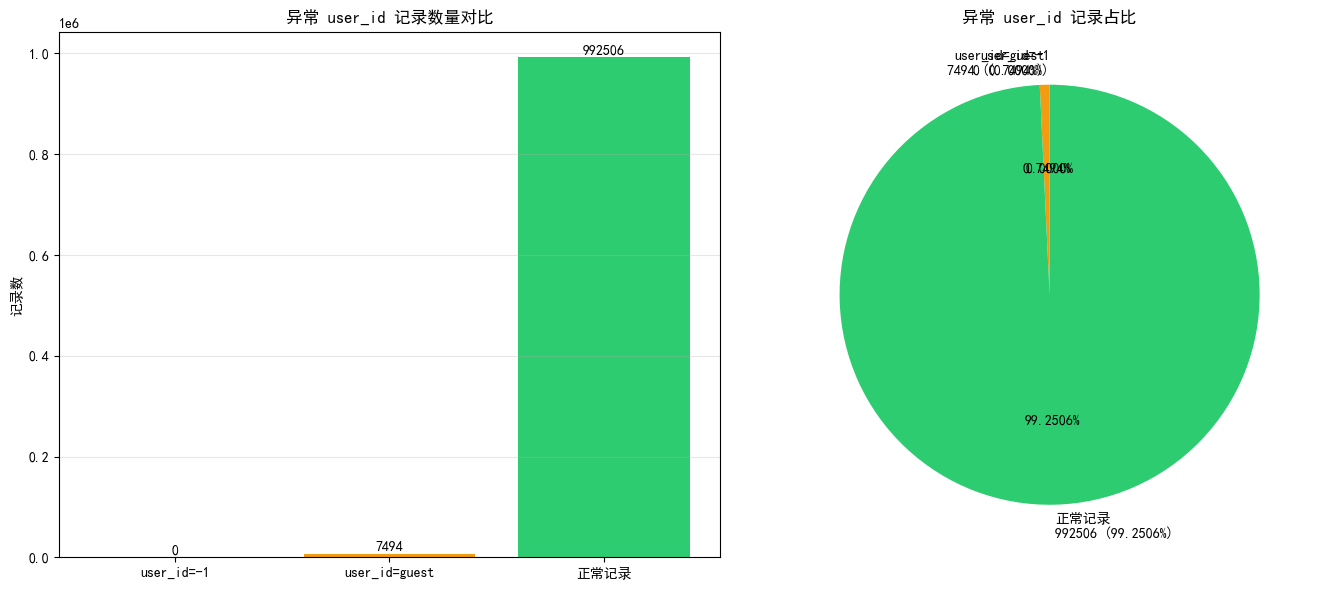


图表已保存为 anomaly_detection.png


In [9]:
# 可视化展示
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 图 1：异常记录对比
categories = ['user_id=-1', 'user_id=guest', '正常记录']
values = [count_minus1, count_guest, len(df) - count_minus1 - count_guest]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = axes[0].bar(categories, values, color=colors)
axes[0].set_title('异常 user_id 记录数量对比')
axes[0].set_ylabel('记录数')
axes[0].grid(axis='y', alpha=0.3)

# 在柱状图上添加数值标签
for bar, value in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                f'{value}', ha='center', va='bottom', fontsize=10)

# 图 2：异常记录占比饼图
if total_anomaly > 0:
    pie_data = [count_minus1, count_guest, len(df) - total_anomaly]
    pie_labels = [f'user_id=-1\n{count_minus1} ({count_minus1/len(df)*100:.4f}%)', 
                  f'user_id=guest\n{count_guest} ({count_guest/len(df)*100:.4f}%)',
                  f'正常记录\n{len(df)-total_anomaly} ({(len(df)-total_anomaly)/len(df)*100:.4f}%)']
    axes[1].pie(pie_data, labels=pie_labels, colors=colors, autopct='%1.4f%%', startangle=90)
    axes[1].set_title('异常 user_id 记录占比')
else:
    axes[1].text(0.5, 0.5, '无异常记录', ha='center', va='center', fontsize=16)
    axes[1].set_title('异常 user_id 记录占比')

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n图表已保存为 anomaly_detection.png")